In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import PartialDependenceDisplay
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = pd.read_csv("configs/ea_results.csv")

# Приводим cross_rate и mut_rate к процентам (в исходных данных они доли 0..1)
percent_cols = ['param_cross_rate', 'param_mut_rate']
for col in percent_cols:
    if col in df.columns:
        df[col] = df[col] * 100

# Извлекаем размер задачи
df['size'] = df['instance'].str.extract(r'chr(\d+)').astype(int)

df.drop(columns=['best_perm', 'status'], inplace=True, errors='ignore')

df['good'] = (df['gap'] < 0.01).astype(int)  # бинарный успех

# Категориальные признаки
cat_params = ['param_strategy', 'param_init_method', 'param_use_local_search']
for c in cat_params:
    df[c] = df[c].astype('category')

num_params = ['param_pop_size', 'param_gens', 'param_cross_rate', 'param_mut_rate','param_tourn_size', 'param_elitism', 'param_ls_freq']

In [29]:
print("Размер данных:", df.shape)
print("\nСтатистика gap:")
print(df['gap'].describe())
display(df.groupby('instance')['gap'].describe())

Размер данных: (147980, 17)

Статистика gap:
count    147980.000000
mean          0.241892
std           0.211583
min           0.000000
25%           0.078200
50%           0.190600
75%           0.353000
max           1.747200
Name: gap, dtype: float64


,count,mean,std,min,25%,50%,75%,max
instance,,,,,,,,
chr12a,10570.0,0.126659,0.129503,0.0000,0.0381,0.0693,0.183200,1.0603
chr12b,10570.0,0.074545,0.145602,0.0000,0.0000,0.0000,0.037000,0.9778
chr12c,10570.0,0.120985,0.112064,0.0000,0.0540,0.0914,0.157800,0.8673
chr15a,10570.0,0.233117,0.180093,0.0000,0.0946,0.1910,0.325000,1.2322
chr15b,10570.0,0.295552,0.217888,0.0000,0.1469,0.2403,0.408300,1.3987
chr15c,10570.0,0.338329,0.198690,0.0000,0.2020,0.3028,0.445500,1.6576
chr18a,10570.0,0.419989,0.213738,0.0000,0.2710,0.3682,0.532300,1.7472
chr18b,10570.0,0.069887,0.065445,0.0000,0.0183,0.0469,0.104300,0.5020
chr20a,10570.0,0.325628,0.150522,0.0000,0.2181,0.2892,0.411500,1.2172


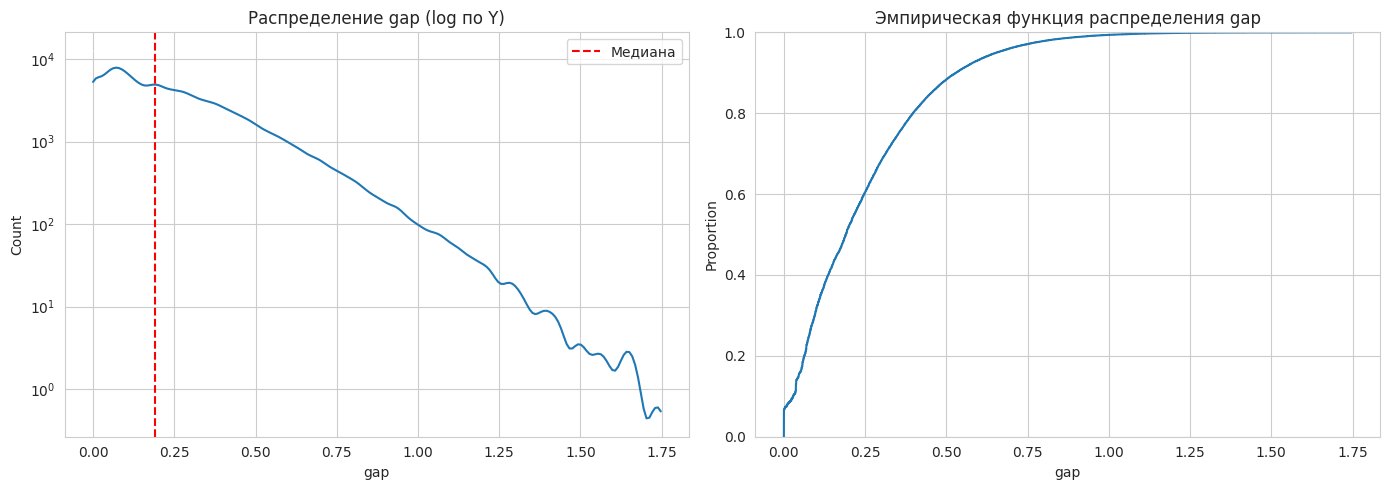

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['gap'], bins=100, kde=True, ax=ax[0], log_scale=(False, True))
ax[0].set_title('Распределение gap (log по Y)')
ax[0].axvline(df['gap'].median(), color='red', linestyle='--', label='Медиана')
ax[0].legend()

sns.ecdfplot(data=df, x='gap', ax=ax[1])
ax[1].set_title('Эмпирическая функция распределения gap')
plt.tight_layout()
plt.show()

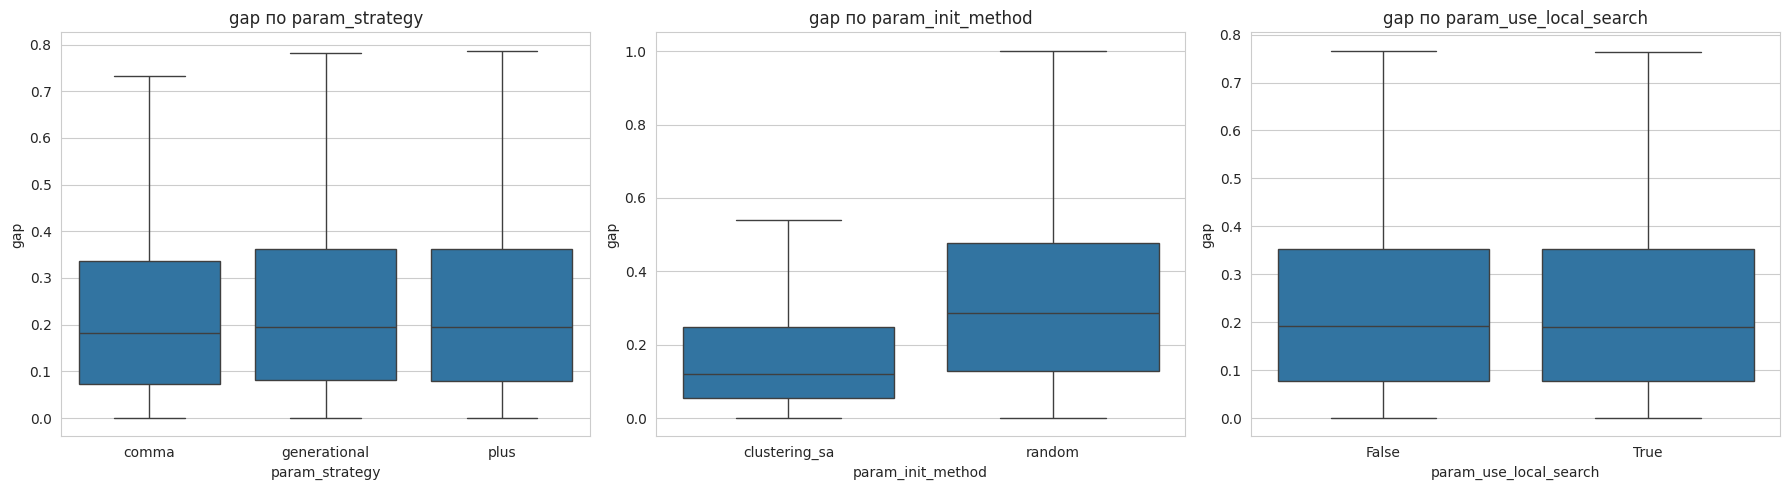

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, col in zip(axes, cat_params):
    sns.boxplot(x=col, y='gap', data=df, ax=ax, showfliers=False)
    ax.set_title(f'gap по {col}')
plt.tight_layout()
plt.show()

In [10]:
for col in cat_params:
    groups = [group['gap'].values for name, group in df.groupby(col, observed=True)]
    try:
        stat, p = kruskal(*groups)
        print(f"{col}: H-статистика = {stat:.2f}, p-value = {p:.6f}")
    except:
        print(f"{col}: не удалось рассчитать критерий")

param_strategy: H-статистика = 235.35, p-value = 0.000000
param_init_method: H-статистика = 21869.26, p-value = 0.000000
param_use_local_search: H-статистика = 0.58, p-value = 0.444527


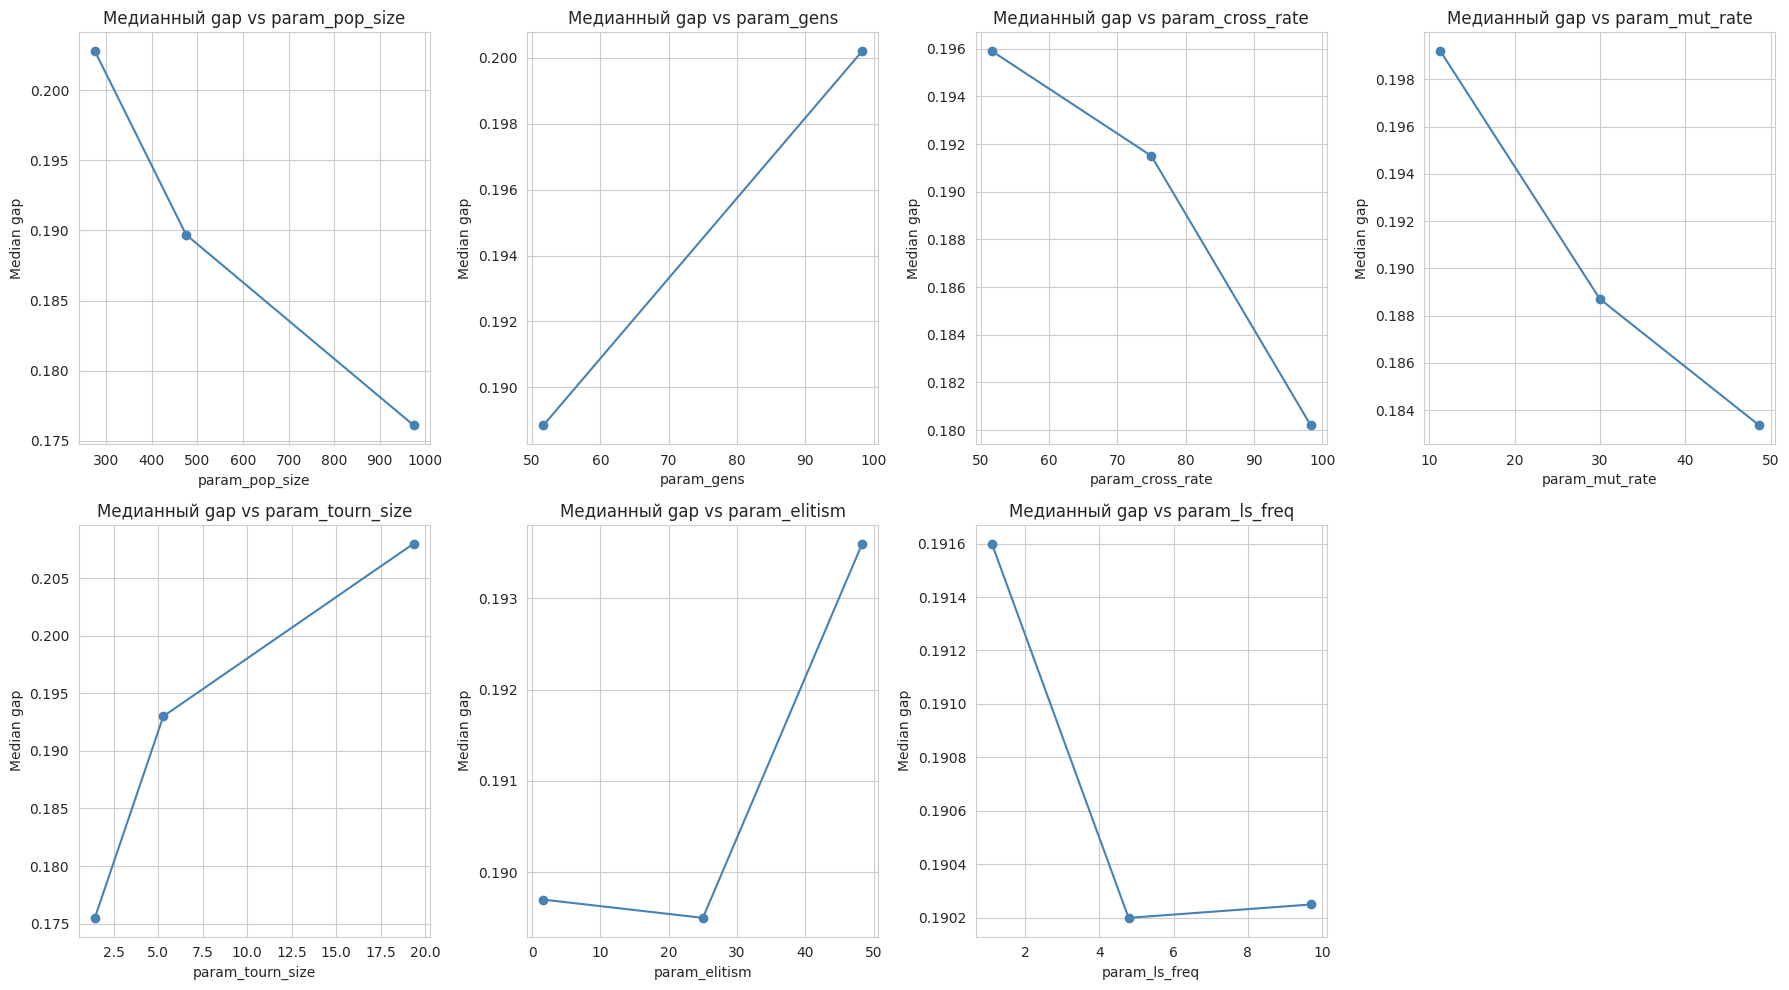

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18,10))
axes = axes.flatten()
for i, col in enumerate(num_params):
    ax = axes[i]
    # Разбиваем на 15 бинов, медианный gap
    df['bin'] = pd.cut(df[col], bins=15)
    grouped = df.groupby('bin', observed=True)['gap'].median().dropna()
    centers = [interv.mid for interv in grouped.index]
    ax.plot(centers, grouped.values, 'o-', color='steelblue')
    ax.set_title(f'Медианный gap vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Median gap')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
df.drop('bin', axis=1, inplace=True)
plt.show()

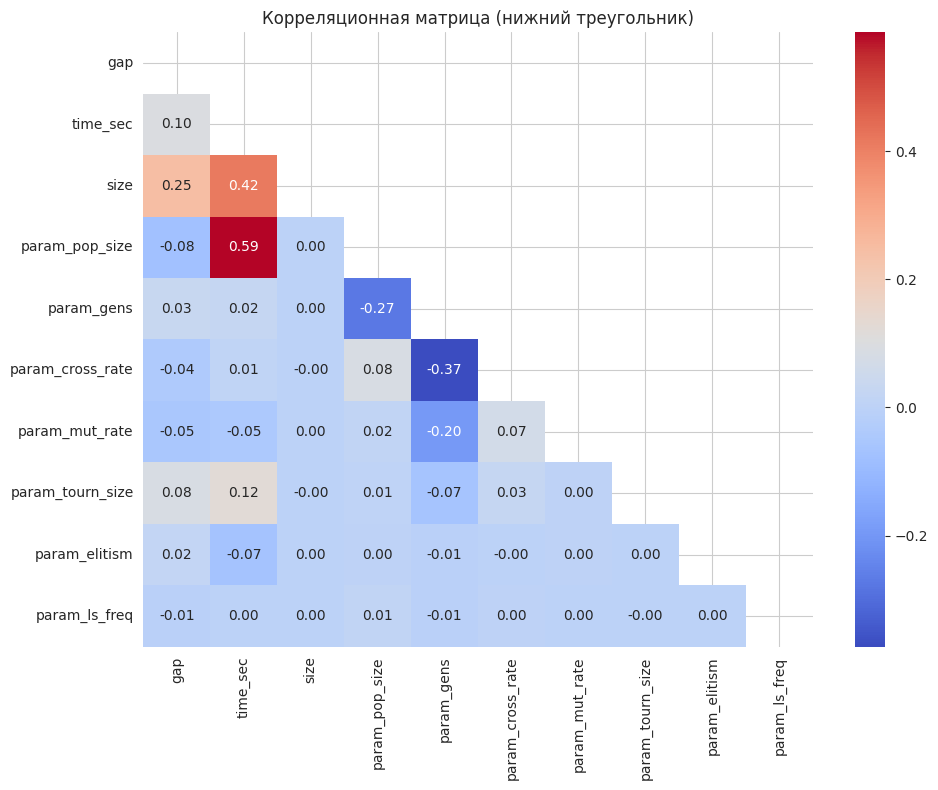

In [12]:
corr_cols = ['gap', 'time_sec', 'size'] + num_params
corr = df[corr_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title('Корреляционная матрица (нижний треугольник)')
plt.tight_layout()
plt.show()

In [16]:
features_num = num_params + ['size']
features_cat = cat_params
X = df[features_num + features_cat].copy()
y = df['gap'].copy()

for col in features_cat:
    X[col] = X[col].astype('category')

y_log = np.log1p(y)  # log(1+gap)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

lgb_reg = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_reg.fit(X_train, y_train,
            categorical_feature=features_cat,
            eval_set=[(X_test, y_test)],
            callbacks=[lgb.early_stopping(50)])

y_pred_log = lgb_reg.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

print(f"R² (log scale): {r2_score(y_test, y_pred_log):.3f}")
print(f"R² (original): {r2_score(y_test_orig, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_orig, y_pred)):.5f}")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[198]	valid_0's l2: 0.0114062
R² (log scale): 0.549
R² (original): 0.519
RMSE: 0.14804


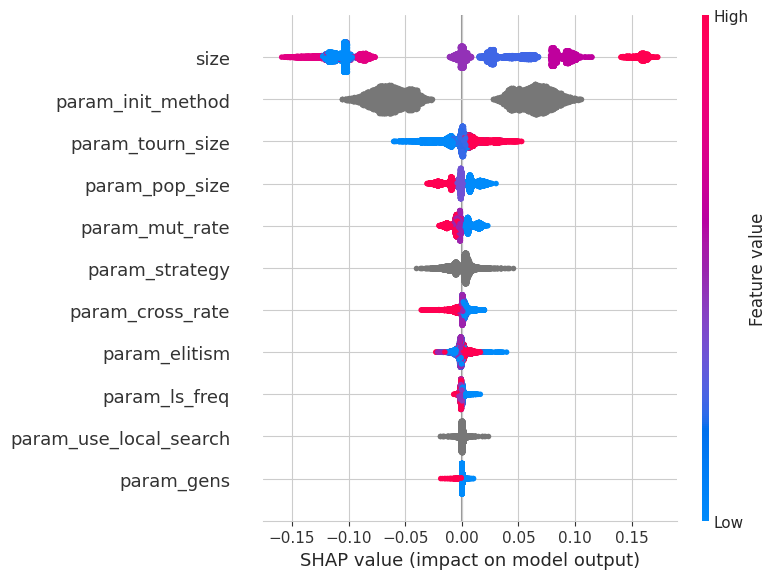

In [17]:
sample_shap = X.sample(min(10000, len(X)), random_state=42)
explainer = shap.TreeExplainer(lgb_reg)
shap_values = explainer.shap_values(sample_shap)
shap.summary_plot(shap_values, sample_shap, max_display=15)

In [18]:
feature_importance = np.abs(shap_values).mean(0)
top_indices = np.argsort(feature_importance)[-3:]
top_features = [sample_shap.columns[i] for i in top_indices]
print("\nТоп-3 признака по SHAP:", top_features)


Топ-3 признака по SHAP: ['param_tourn_size', 'param_init_method', 'size']


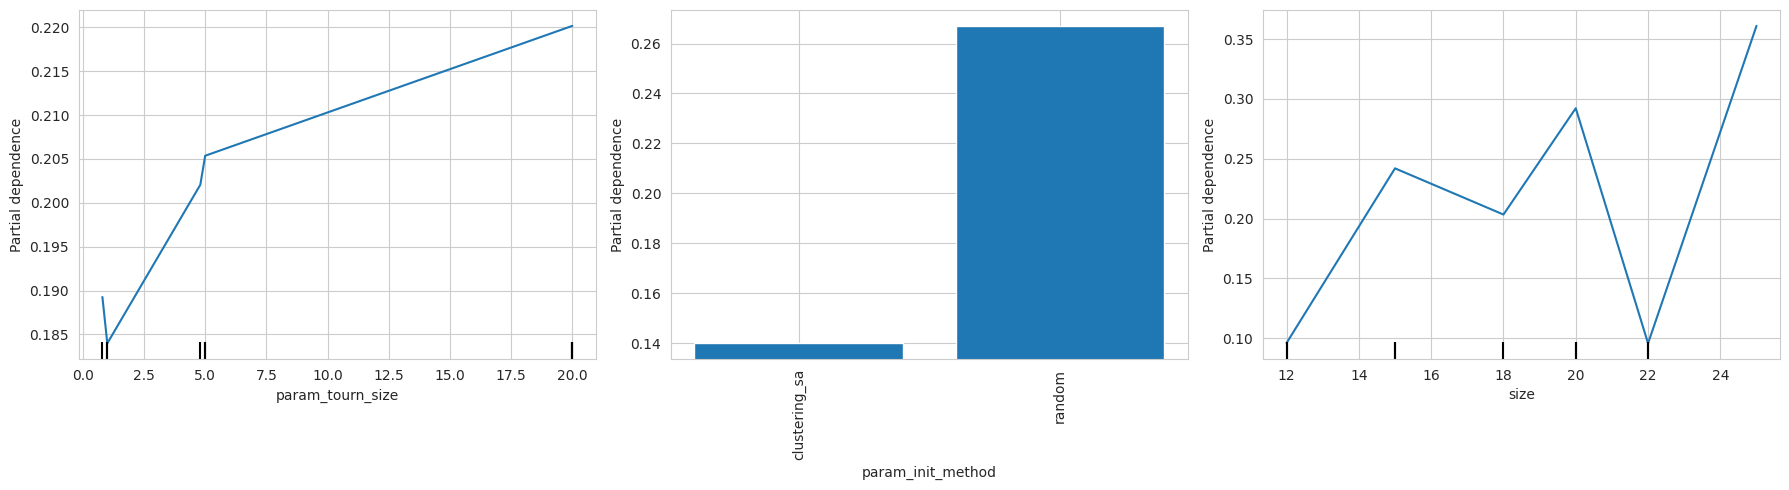

In [ ]:
X_float = X.copy()
for col in X_float.select_dtypes(include=['int64', 'int32']).columns:
    X_float[col] = X_float[col].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for i, feat in enumerate(top_features):
    PartialDependenceDisplay.from_estimator(
        lgb_reg, X_float, [feat],
        categorical_features=features_cat,
        ax=axes[i],
        grid_resolution=50
    )
plt.tight_layout()
plt.show()

In [20]:
y_good = df['good']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_good, test_size=0.2, random_state=42, stratify=y_good)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_clf.fit(X_train_c, y_train_c,
            categorical_feature=features_cat,
            eval_set=[(X_test_c, y_test_c)],
            callbacks=[lgb.early_stopping(30)])

y_pred_proba = lgb_clf.predict_proba(X_test_c)[:,1]
print("ROC AUC (good):", roc_auc_score(y_test_c, y_pred_proba))
print("\nClassification report:\n", classification_report(y_test_c, lgb_clf.predict(X_test_c)))


Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[299]	valid_0's binary_logloss: 0.400269
ROC AUC (good): 0.9020279384001093

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.79      0.88     27258
           1       0.26      0.87      0.40      2338

    accuracy                           0.79     29596
   macro avg       0.62      0.83      0.64     29596
weighted avg       0.93      0.79      0.84     29596



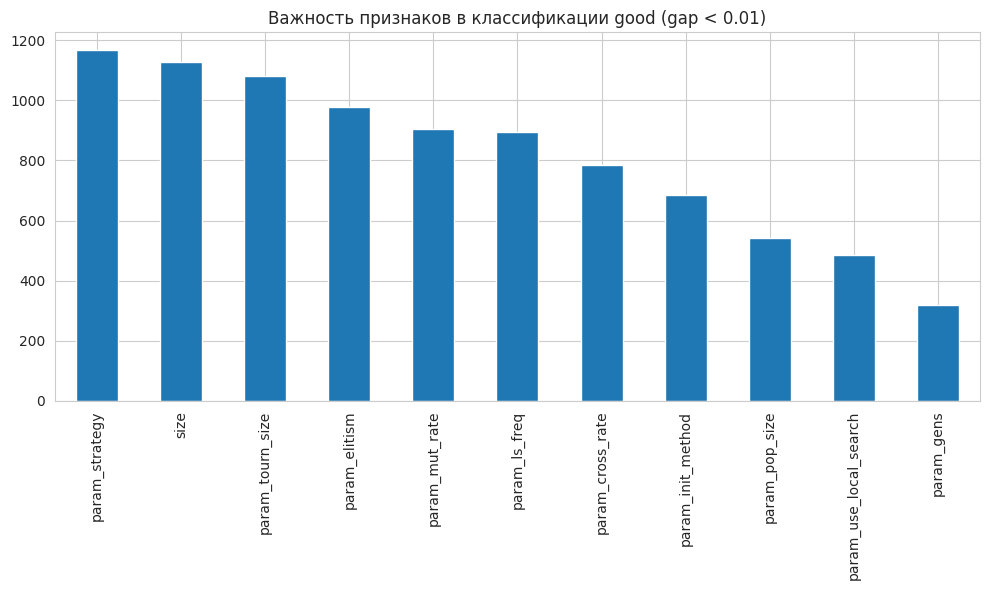

In [21]:
clf_importances = pd.Series(lgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
clf_importances.plot(kind='bar')
plt.title('Важность признаков в классификации good (gap < 0.01)')
plt.tight_layout()
plt.show()

In [22]:
# %% Парето-фронт время/качество для нескольких инстансов
def pareto_frontier(X):
    X = np.asarray(X)
    sorted_idx = np.lexsort((X[:,1], X[:,0]))
    front = []
    min_y = float('inf')
    for idx in sorted_idx:
        if X[idx,1] < min_y:
            front.append(X[idx])
            min_y = X[idx,1]
    return np.array(front)

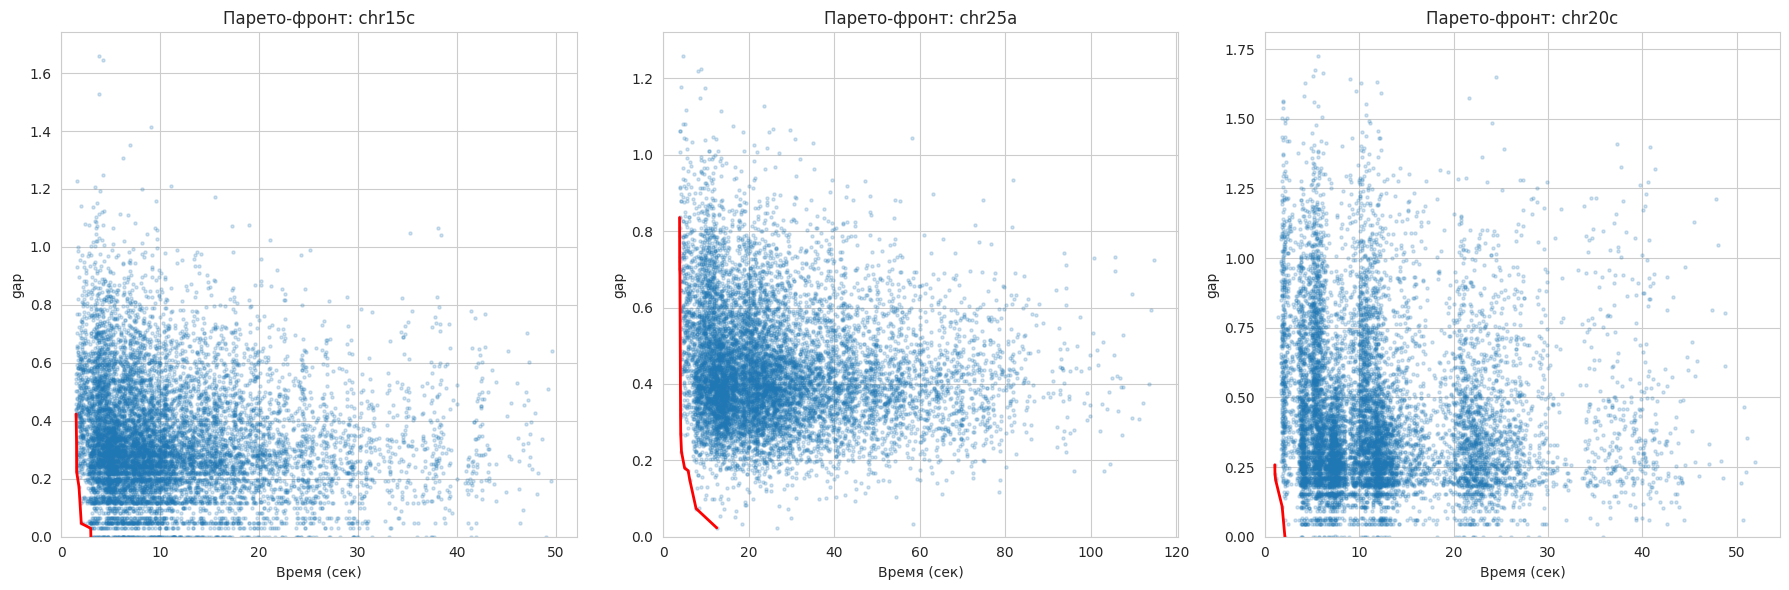

In [25]:
instances_to_plot = ['chr15c','chr25a', 'chr20c']
fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, inst in zip(axes, instances_to_plot):
    subset = df[df['instance'] == inst]
    points = subset[['time_sec', 'gap']].drop_duplicates().values
    if len(points) == 0:
        continue
    front = pareto_frontier(points)
    ax.scatter(points[:,0], points[:,1], alpha=0.2, s=5)
    ax.plot(front[:,0], front[:,1], 'r-', lw=2)
    ax.set_title(f'Парето-фронт: {inst}')
    ax.set_xlabel('Время (сек)')
    ax.set_ylabel('gap')
    ax.set_xlim(0, points[:,0].max()*1.05)
    ax.set_ylim(0, points[:,1].max()*1.05)
plt.tight_layout()
plt.show()

In [26]:
# %% Кластеризация конфигураций (без gap/time, чтобы увидеть типы настроек)
# Используем только параметры алгоритма + размер задачи
cluster_features = df[num_params + ['size']].dropna()
# Стандартизируем
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

# Возьмём подвыборку 100k для скорости кластеризации
sample_idx = np.random.choice(scaled.shape[0], min(100000, scaled.shape[0]), replace=False)
scaled_sample = scaled[sample_idx]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_sample)
cluster_df = cluster_features.iloc[sample_idx].copy()
cluster_df['cluster'] = clusters

# Профили кластеров (средние значения параметров и медианный gap)
cluster_profile = cluster_df.copy()
cluster_profile['gap'] = df.iloc[sample_idx]['gap'].values
cluster_profile['time_sec'] = df.iloc[sample_idx]['time_sec'].values
cluster_summary = cluster_profile.groupby('cluster').agg(
    **{col: (col, 'mean') for col in num_params},
    size_mean=('size', 'mean'),
    gap_median=('gap', 'median'),
    time_median=('time_sec', 'median'),
    count=('gap', 'count')
)
display(cluster_summary)

,param_pop_size,param_gens,param_cross_rate,param_mut_rate,param_tourn_size,param_elitism,param_ls_freq,size_mean,gap_median,time_median,count
cluster,,,,,,,,,,,
0,372.355518,50.0,74.523263,30.086793,2.912155,25.117062,2.892794,17.573378,0.1895,5.580,23965
1,348.566368,50.0,74.652453,30.139019,6.300749,24.925478,10.000000,17.577663,0.1936,5.280,14962
2,367.257808,100.0,55.230281,21.823187,7.226300,24.594082,5.201938,17.570090,0.1967,9.675,18890
3,1000.000000,50.0,74.551922,30.461038,3.032096,24.743561,5.332267,17.546297,0.1611,16.670,18133
4,631.153846,50.0,74.892931,29.838669,20.000000,25.064091,4.687634,17.565322,0.2025,12.000,24050
